## Muhammad Nauman

## Heart Disease Prediction using different ML Algorithms

## Importing Important Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay,matthews_corrcoef
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import RocCurveDisplay
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier

## Load the dataset

In [7]:
data = pd.read_csv(r"C:\Users\Laptop\Desktop\Nauman Heart Disease prediction\heart.csv",sep=',')
df=pd.DataFrame(data)
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  


## Data Preprocessing

Convert categorical features to a numerical and then scale them using StandardScaler

In [10]:
# missing values
print(df.isnull().sum())

# Conversion
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

#scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('target', axis=1))
df_scaled = pd.DataFrame(scaled_features, columns=df.columns[:-1])
df_scaled['target'] = df['target']

print(df_scaled.head())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
        age  trestbps      chol   thalach   oldpeak  target     sex_1  \
0  0.952197  0.763956 -0.256334  0.015443  1.087338       1 -0.444554   
1 -1.915313 -0.092738  0.072199  1.633471  2.122573       1 -0.444554   
2 -1.474158 -0.092738 -0.816773  0.977514  0.310912       1  2.249444   
3  0.180175 -0.663867 -0.198357  1.239897 -0.206705       1  2.249444   
4  0.290464 -0.663867  2.082050  0.583939 -0.379244       1 -0.444554   

       cp_1      cp_2      cp_3  ...  restecg_2   exang_1   slope_1   slope_2  \
0 -0.634648  3.489114  2.394438  ...  -0.696631 -0.926766 -0.939142 -0.522599   
1  1.575677 -0.286606 -0.417635  ...  -0.696631 -0.926766 -0.939142 -0.522599   
2 -0.634648 -0.286606 -0.417635  ...  -0.696631 -0.926766  1.064802 -0.522599   
3 -0.634648 -0.286606 -0.417

Histogram to show distribution of all numerical features

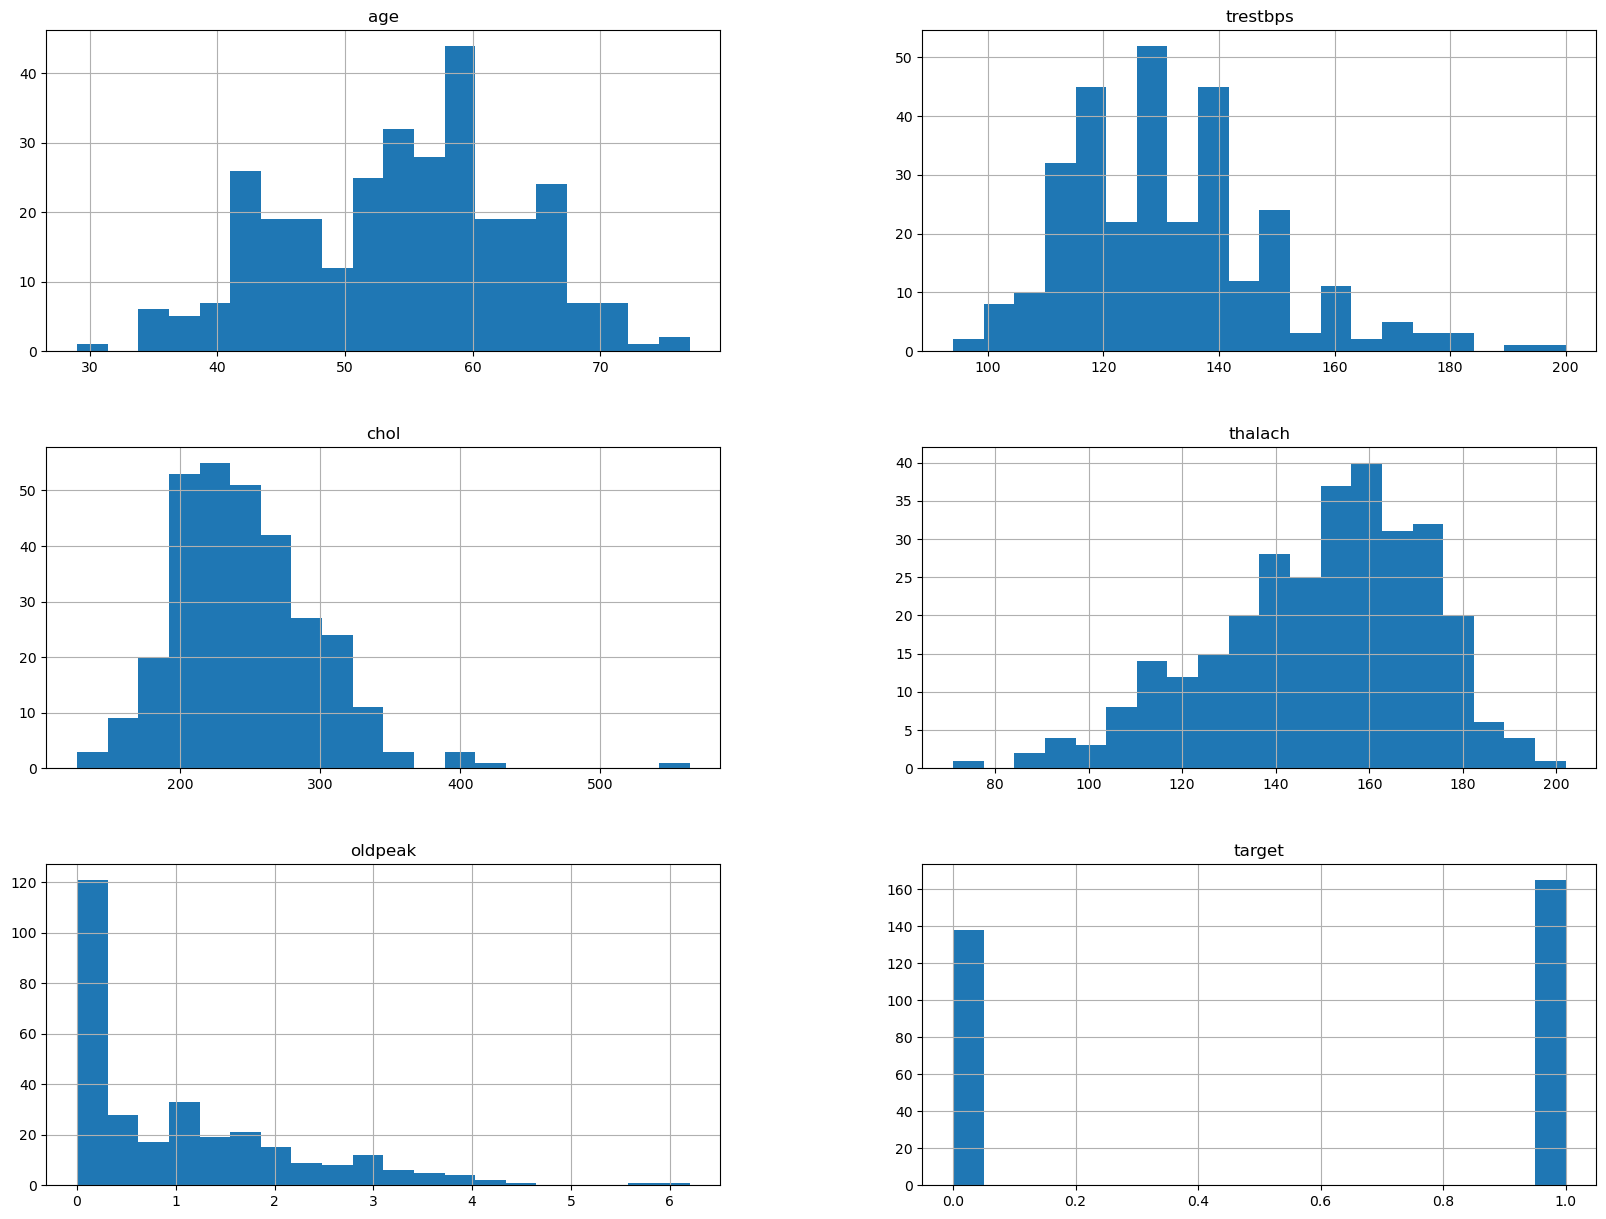

In [12]:
df.hist(bins=20, figsize=(20, 15))
plt.show()

Visualize Cholestrol levels in comparison to heart disease

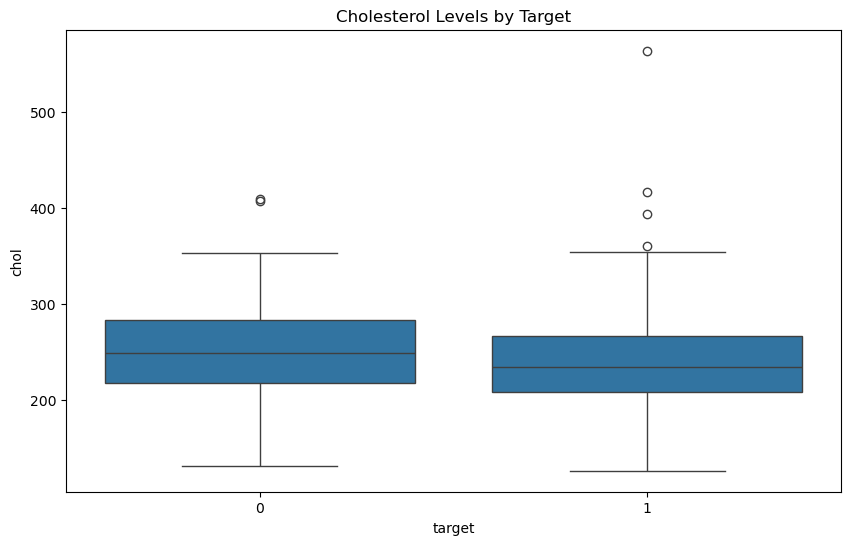

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='chol', data=df)
plt.title('Cholesterol Levels by Target')
plt.show()

## Comparison of Age and Heart Rate

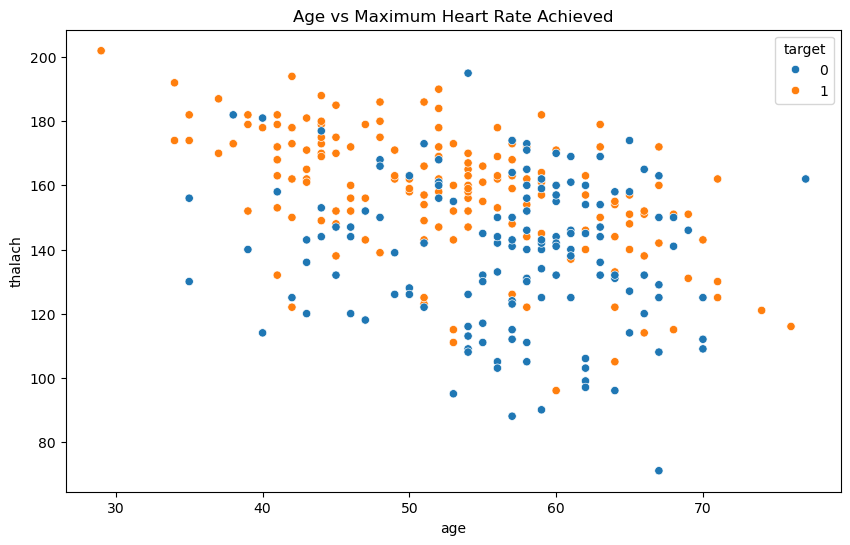

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='thalach', hue='target', data=df)
plt.title('Age vs Maximum Heart Rate Achieved')
plt.show()

## Comparison of heart disease ratio in Males and Females

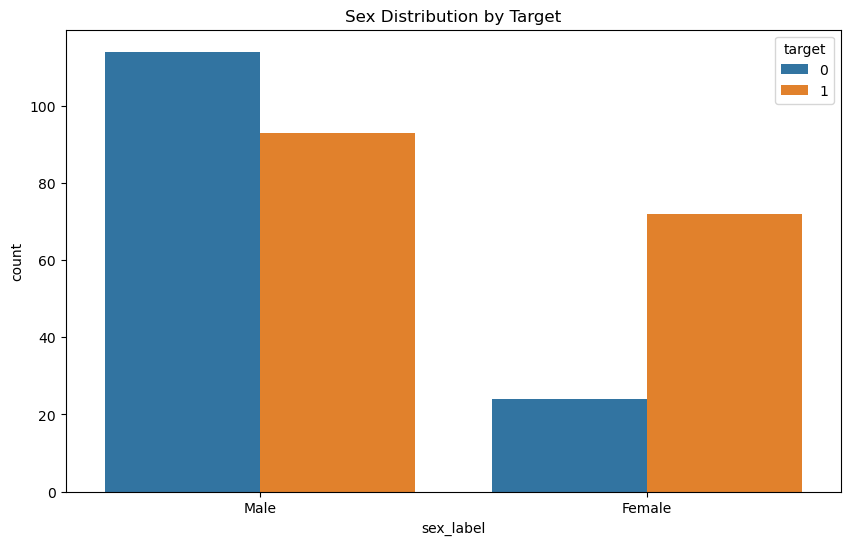

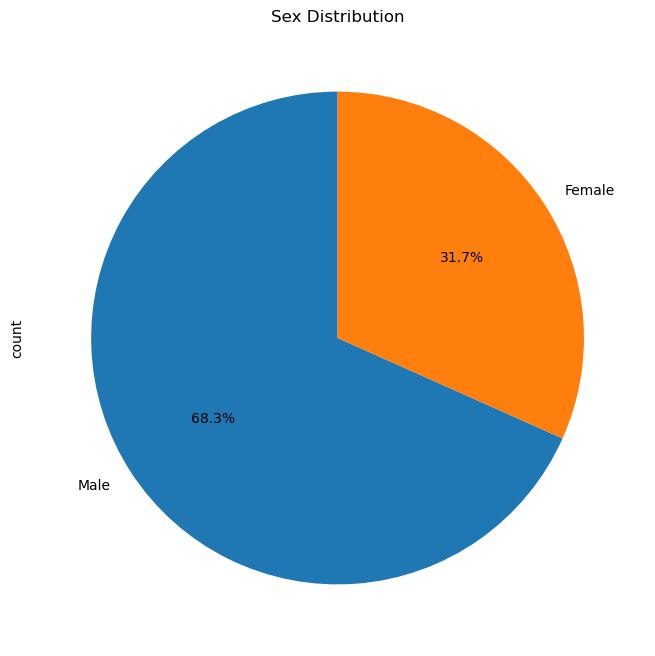

In [18]:
df['sex_label'] = df['sex_1'].map({True: 'Male', False: 'Female'})
plt.figure(figsize=(10, 6))
sns.countplot(x='sex_label', hue='target', data=df)
plt.title('Sex Distribution by Target')
plt.show()

# Ratio
df['sex_label'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, figsize=(8, 8), title='Sex Distribution')
plt.show()

df.drop(columns=['sex_label'], inplace=True)

## Correlation matrix of all features

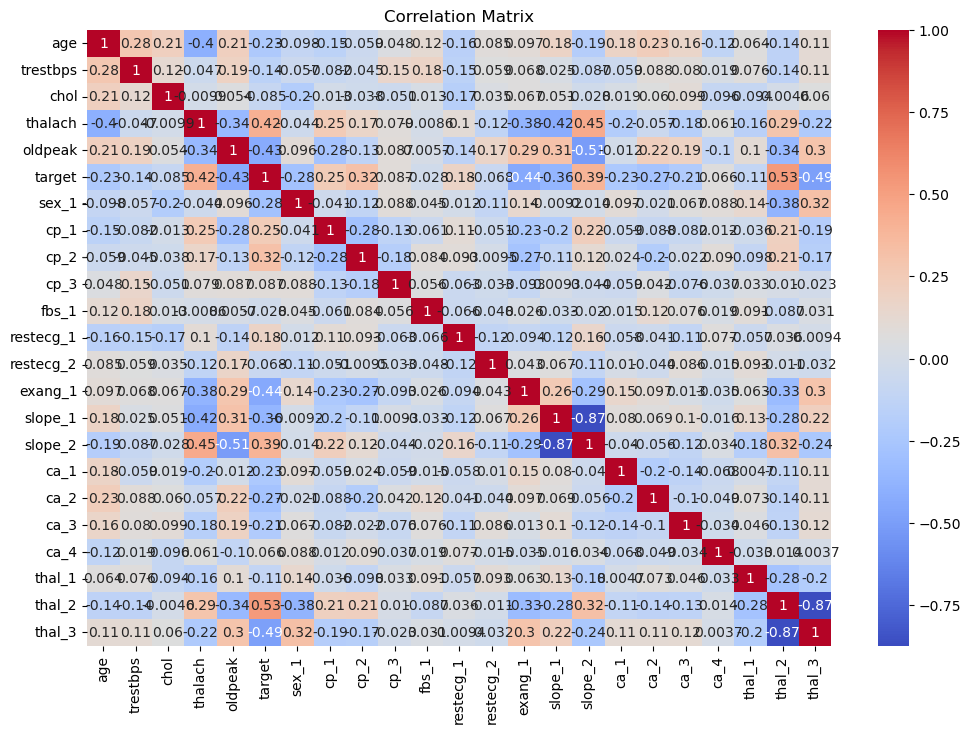

In [20]:
# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## Comparison of Age, Heart rate and heart disease

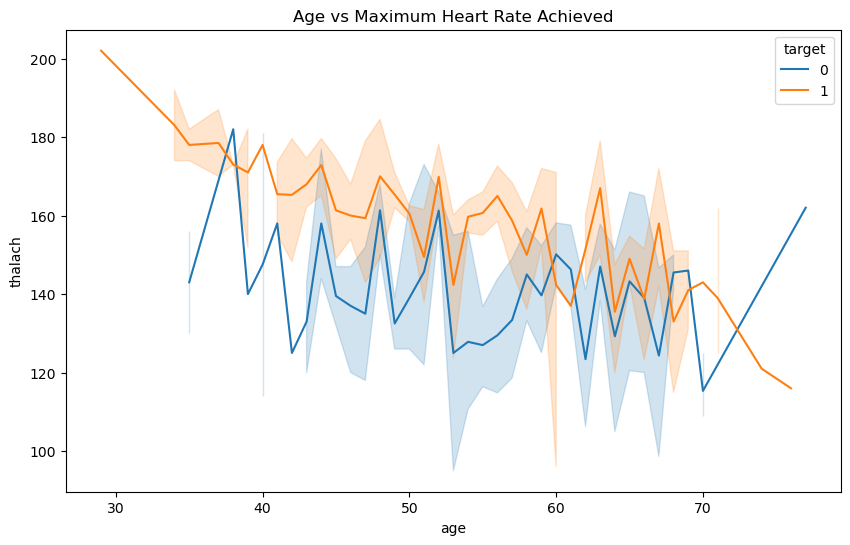

In [22]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='age', y='thalach', hue='target', data=df)
plt.title('Age vs Maximum Heart Rate Achieved')
plt.show()


## Split dataset into training and testing with 80:20 ratio

In [24]:
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=192)



## Training and evaluation of Logistic Regression

Logistic Regression Results:
Accuracy: 0.8689
MCC:      0.7338
Classification Report (Logistic Regression):
              precision    recall  f1-score   support

           0       0.91      0.86      0.89        36
           1       0.81      0.88      0.85        25

    accuracy                           0.87        61
   macro avg       0.86      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



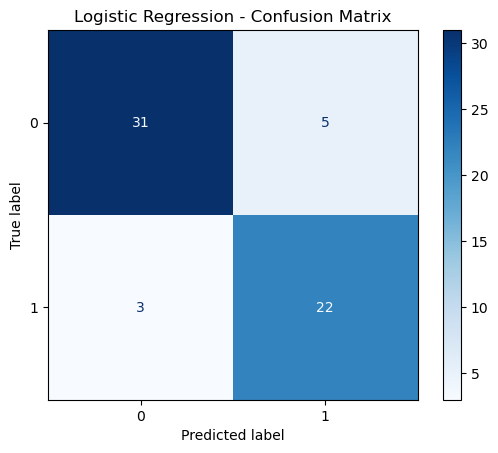

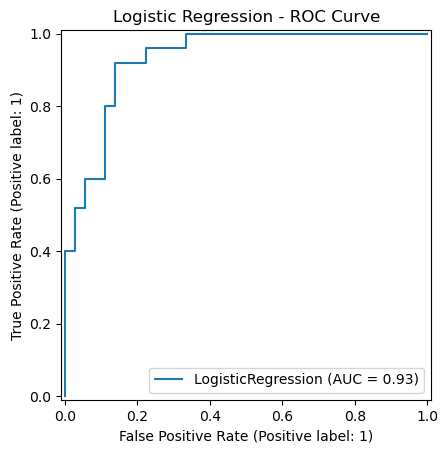

In [26]:
model_scores = {}
model_lgr = LogisticRegression(random_state=192)
model_lgr.fit(X_train, y_train)

y_pred_model_lgr = model_lgr.predict(X_test)

accuracy_model_lgr = accuracy_score(y_test, y_pred_model_lgr)
mcc_model_lgr = matthews_corrcoef(y_test, y_pred_model_lgr)
model_scores["Logistic Regression"] = {"Accuracy": accuracy_model_lgr,"MCC": mcc_model_lgr}
print(f"Logistic Regression Results - Accuracy: {accuracy_model_lgr:.4f}, MCC: {mcc_model_lgr:.4f}")
print(f"Classification Report (Logistic Regression):\n{classification_report(y_test, y_pred_model_lgr)}")


ConfusionMatrixDisplay.from_estimator(model_lgr, X_test, y_test, cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model_lgr, X_test, y_test)
plt.title("Logistic Regression - ROC Curve")
plt.show()


## KNN


model_knr Results:
Classification Report (model_knr):
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        36
           1       0.78      0.84      0.81        25

    accuracy                           0.84        61
   macro avg       0.83      0.84      0.83        61
weighted avg       0.84      0.84      0.84        61

Accuracy: 0.8361
MCC:      0.6667


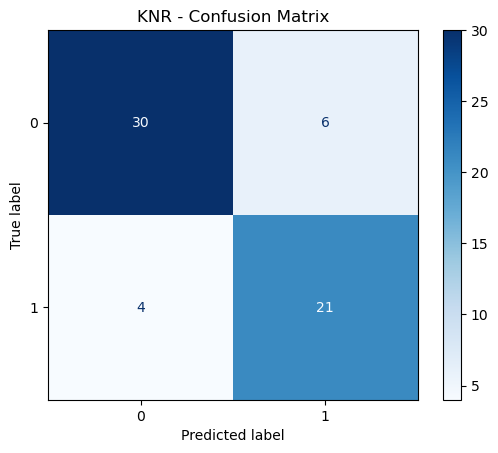

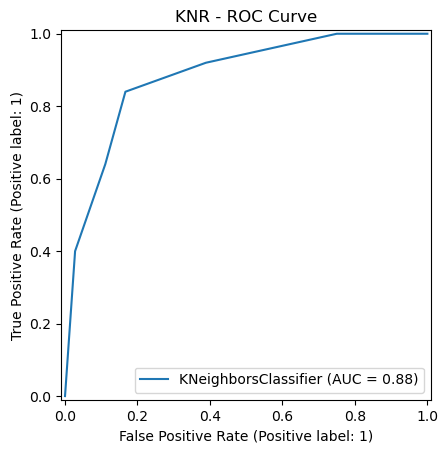

In [28]:
model_knr = KNeighborsClassifier(n_neighbors=5)
model_knr.fit(X_train, y_train)

y_pred_model_knr = model_knr.predict(X_test)

#Evaluation
accuracy_model_knr = accuracy_score(y_test, y_pred_model_knr)
mcc_model_knr = matthews_corrcoef(y_test, y_pred_model_knr)
model_scores["model_knr"] = {"Accuracy": accuracy_model_knr,"MCC": mcc_model_knr}

print(f"\n KNN Results:\n{classification_report(y_test, y_pred_model_knr)}\nAccuracy: {accuracy_model_knr:.4f}, MCC: {mcc_model_knr:.4f}")

ConfusionMatrixDisplay.from_estimator(model_knr, X_test, y_test, cmap='Blues')
plt.title("KNR - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model_knr, X_test, y_test)
plt.title("KNR - ROC Curve")
plt.show()


## Decision Tree


Decision Tree Results:
Classification Report (Decision Tree):
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        36
           1       0.66      0.76      0.70        25

    accuracy                           0.74        61
   macro avg       0.73      0.74      0.73        61
weighted avg       0.75      0.74      0.74        61

Accuracy: 0.7377
MCC:      0.4749


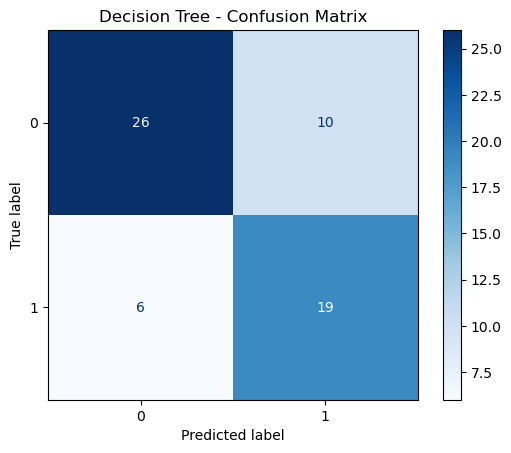

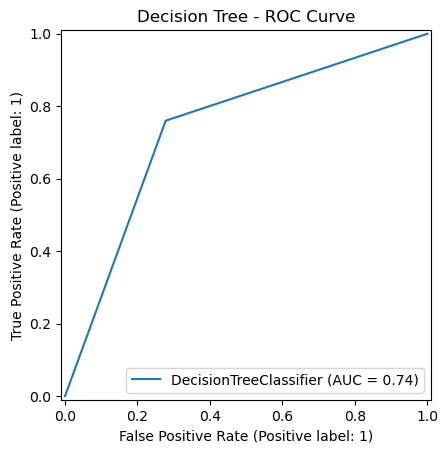

In [30]:
model_dt = DecisionTreeClassifier(random_state=192)
model_dt.fit(X_train, y_train)

y_pred_model_dt = model_dt.predict(X_test)

#Evaluation
accuracy_model_dt = accuracy_score(y_test, y_pred_model_dt)
mcc_model_dt = matthews_corrcoef(y_test, y_pred_model_dt)
model_scores["Decision Tree"] = {"Accuracy": accuracy_model_dt,"MCC": mcc_model_dt}

print(f"\nDecision Tree Results:\n{classification_report(y_test, y_pred_model_dt)}\nAccuracy: {accuracy_model_dt:.4f}, MCC: {mcc_model_dt:.4f}")


ConfusionMatrixDisplay.from_estimator(model_dt, X_test, y_test, cmap='Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model_dt, X_test, y_test)
plt.title("Decision Tree - ROC Curve")
plt.show()


## Random Forest


Random Forest Results:
Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.89      0.86      0.87        36
           1       0.81      0.84      0.82        25

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

Accuracy: 0.8525
MCC:      0.6972


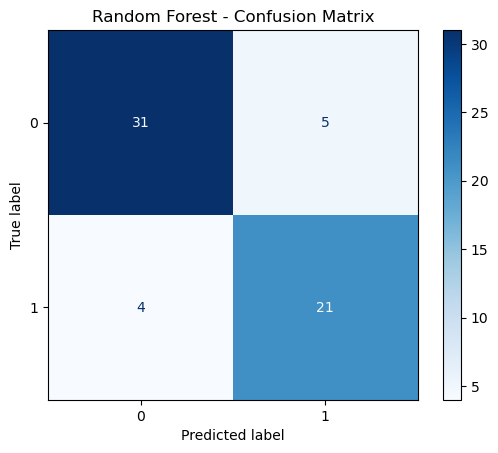

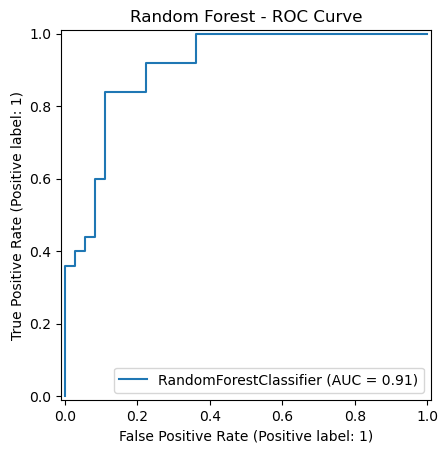

In [32]:
model_rf = RandomForestClassifier(random_state=192)
model_rf.fit(X_train, y_train)

y_pred_model_rf = model_rf.predict(X_test)

#Evaluation
accuracy_model_rf = accuracy_score(y_test, y_pred_model_rf)
mcc_model_rf = matthews_corrcoef(y_test, y_pred_model_rf)
model_scores["Random Forest"] = {"Accuracy": accuracy_model_rf,"MCC": mcc_model_rf}

print(f"\nRandom Forest Results:\n{classification_report(y_test, y_pred_model_rf)}\nAccuracy: {accuracy_model_rf:.4f}, MCC: {mcc_model_rf:.4f}")


ConfusionMatrixDisplay.from_estimator(model_rf, X_test, y_test, cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model_rf, X_test, y_test)
plt.title("Random Forest - ROC Curve")
plt.show()


## SVM


model_svm Results:
Classification Report (model_svm):
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        36
           1       0.78      0.84      0.81        25

    accuracy                           0.84        61
   macro avg       0.83      0.84      0.83        61
weighted avg       0.84      0.84      0.84        61

Accuracy: 0.8361
MCC:      0.6667


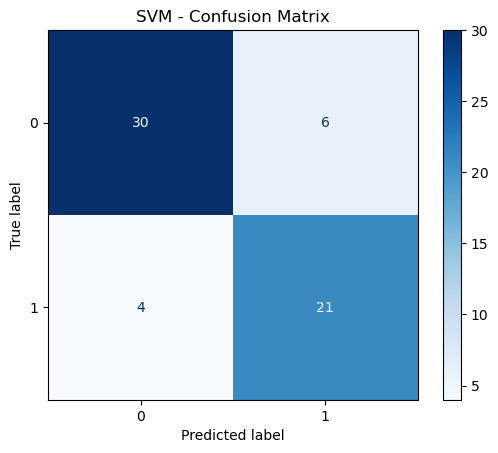

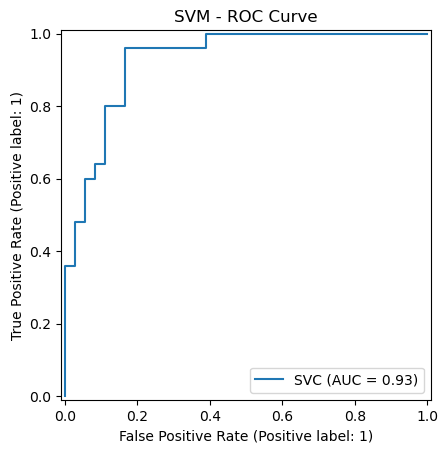

In [34]:
model_svm = SVC(probability=True, random_state=192)
model_svm.fit(X_train, y_train)

y_pred_model_svm = model_svm.predict(X_test)

#Evaluation
accuracy_model_svm = accuracy_score(y_test, y_pred_model_svm)
mcc_model_svm = matthews_corrcoef(y_test, y_pred_model_svm)
model_scores["model_svm"] = {"Accuracy": accuracy_model_svm,"MCC": mcc_model_svm}

print(f"\nmodel_svm Results:\n{classification_report(y_test, y_pred_model_svm)}\nAccuracy: {accuracy_model_svm:.4f}, MCC: {mcc_model_svm:.4f}")

ConfusionMatrixDisplay.from_estimator(model_svm, X_test, y_test, cmap='Blues')
plt.title("SVM - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model_svm, X_test, y_test)
plt.title("SVM - ROC Curve")
plt.show()

## Neural Network


model_ann  Results:
Classification Report (model_ann):
              precision    recall  f1-score   support

           0       0.59      1.00      0.74        36
           1       0.00      0.00      0.00        25

    accuracy                           0.59        61
   macro avg       0.30      0.50      0.37        61
weighted avg       0.35      0.59      0.44        61

Accuracy: 0.5902
MCC:      0.0000


C:\Users\Laptop\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Laptop\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Laptop\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Laptop\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-d

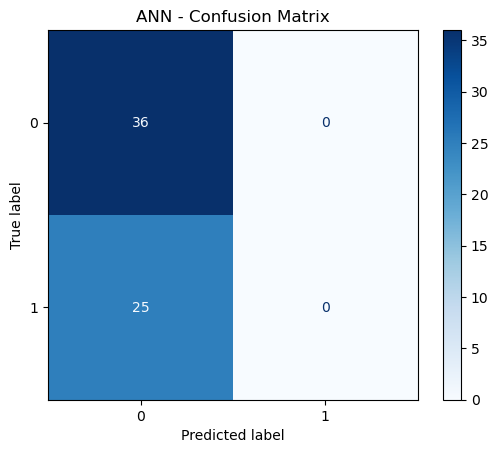

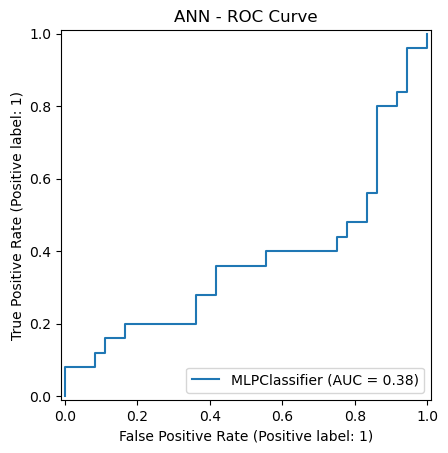

In [36]:
model_nn = MLPClassifier(hidden_layer_sizes=(32,16), max_iter=2, random_state=192)
model_nn.fit(X_train, y_train)

y_pred_model_nn = model_ann.predict(X_test)

#Evaluation
accuracy_model_nn = accuracy_score(y_test, y_pred_model_nn)
mcc_model_nn = matthews_corrcoef(y_test, y_pred_model_nn)
model_scores["model_nn"] = {"Accuracy": accuracy_model_nn,"MCC": mcc_model_nn}

print(f"\nNeural Networks Results:\n{classification_report(y_test, y_pred_model_nn)}\nAccuracy: {accuracy_model_nn:.4f}, MCC: {mcc_model_nn:.4f}")

ConfusionMatrixDisplay.from_estimator(model_ann, X_test, y_test, cmap='Blues')
plt.title("ANN - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model_ann, X_test, y_test)
plt.title("ANN - ROC Curve")
plt.show()

## Comparison of all Classification Algorithms that we have trained

All Model Scores:


,Accuracy,MCC
Logistic Regression,0.868852,0.733809
model_knr,0.836066,0.666699
Decision Tree,0.737705,0.474892
Random Forest,0.852459,0.697248
model_svm,0.836066,0.666699
model_ann,0.590164,0.000000


Highest Accuracy: Logistic Regression = 0.8689
Highest MCC:     Logistic Regression   = 0.7338


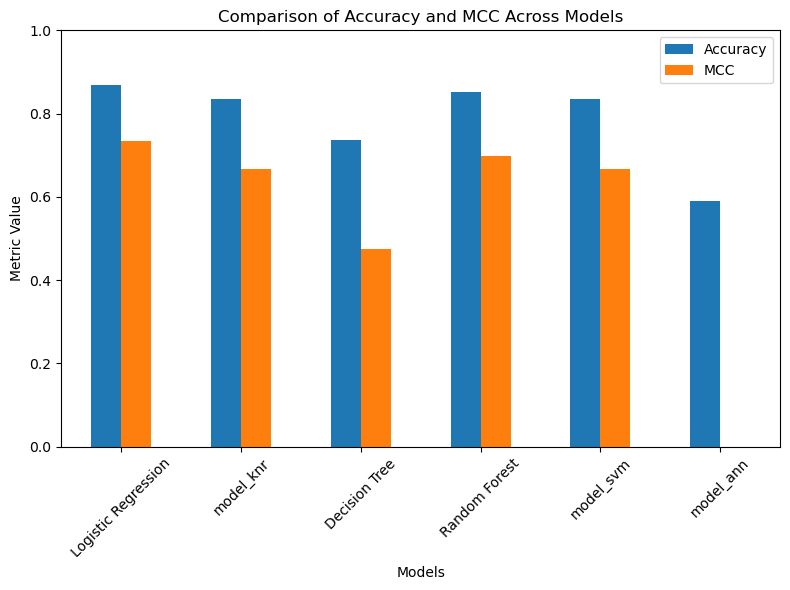

In [38]:
scores_df = pd.DataFrame(model_scores).T 

print("All Model Scores:")
display(scores_df)

best_acc_model = scores_df['Accuracy'].idxmax()
best_acc_val = scores_df['Accuracy'].max()

best_mcc_model = scores_df['MCC'].idxmax()
best_mcc_val = scores_df['MCC'].max()

print(f"Highest Accuracy: {best_acc_model} = {best_acc_val:.4f}")
print(f"Highest MCC:     {best_mcc_model}   = {best_mcc_val:.4f}")


scores_df.plot(kind='bar', figsize=(8,6))
plt.title("Comparison of Accuracy and MCC Across Models")
plt.xlabel("Models")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


## Visualize Accuracy score and MCC using Slope chart

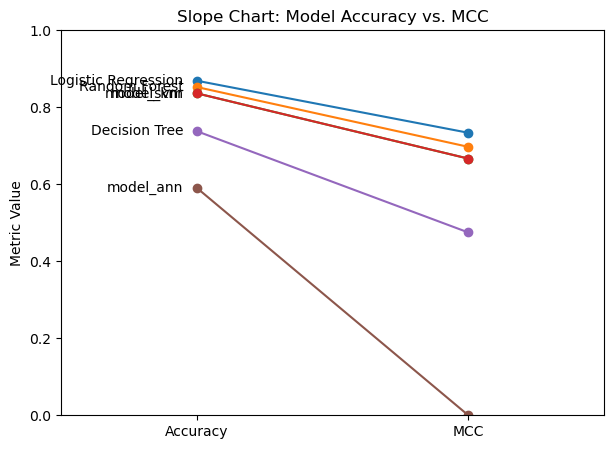

In [40]:
scores_sorted = scores_df.sort_values(by="Accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
x_left, x_right = 1, 2

for i, (model_name, row) in enumerate(scores_sorted.iterrows()):
    acc = row["Accuracy"]
    mcc = row["MCC"]
    ax.plot([x_left, x_right], [acc, mcc], marker='o')
    ax.text(x_left - 0.05, acc, model_name, ha='right', va='center')
    
ax.set_xlim(0.5, 2.5)
ax.set_xticks([x_left, x_right])
ax.set_xticklabels(["Accuracy", "MCC"])
ax.set_ylabel("Metric Value")
ax.set_title("Slope Chart: Model Accuracy vs. MCC")
plt.ylim(0, 1)
plt.show()


## Model Optimization
KNN performed with the best Accuracy and MCC so we will try to improve it further using RandomizedGridsearchCV to find optimal parameters for model_knr

Best model_knr Parameters: {'weights': 'distance', 'p': 2, 'n_neighbors': 25}

model_knr (Tuned) Results on Test Set:
Accuracy: 0.8525
MCC:      0.7138

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87        36
           1       0.77      0.92      0.84        25

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.87      0.85      0.85        61



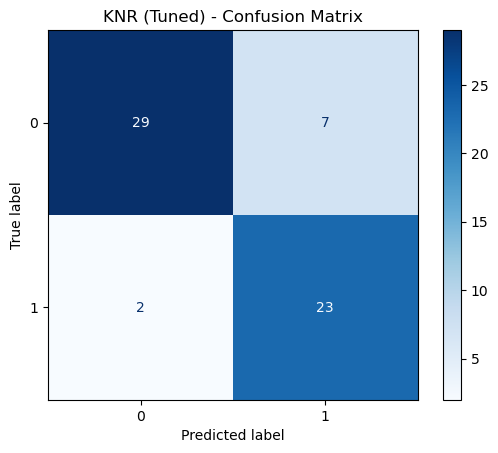

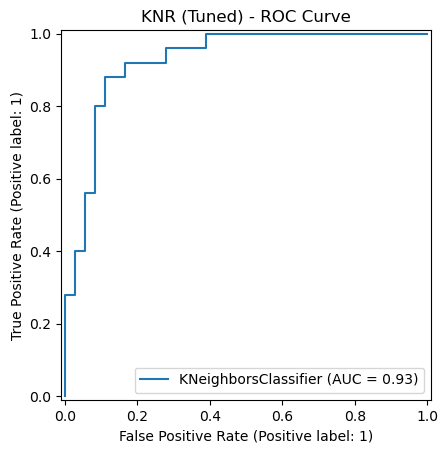

In [42]:
param_distributions = {
    'n_neighbors': range(1, 30),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
model_knr_base = KNeighborsClassifier()

model_knr_random_search = RandomizedSearchCV(estimator=model_knr_base,param_distributions=param_distributions,n_iter=20,scoring='accuracy',cv=5,random_state=192,n_jobs=-1)

model_knr_random_search.fit(X_train, y_train)

print("Best model_knr Parameters:", model_knr_random_search.best_params_)

#Evaluate
model_knr_best = model_knr_random_search.best_estimator_
y_pred_model_knr_best = model_knr_best.predict(X_test)

accuracy_model_knr_best = accuracy_score(y_test, y_pred_model_knr_best)
mcc_model_knr_best = matthews_corrcoef(y_test, y_pred_model_knr_best)

print(f"\nmodel_knr (Tuned) Results on Test Set:\n{classification_report(y_test, y_pred_model_knr_best)}\nAccuracy: {accuracy_model_knr_best:.4f}, MCC: {mcc_model_knr_best:.4f}")


ConfusionMatrixDisplay.from_estimator(model_knr_best, X_test, y_test, cmap='Blues')
plt.title("KNR (Tuned) - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(model_knr_best, X_test, y_test)
plt.title("KNR (Tuned) - ROC Curve")
plt.show()

## Ensemble Methods

Top 3 candidates with top Accuracy and MCC are model_knr, Random Forest and Logistic Regression

Ensemble (Soft Voting) Results:
Accuracy: 0.8525
MCC:      0.7040

Classification Report (Soft Voting Ensemble):
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        36
           1       0.79      0.88      0.83        25

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



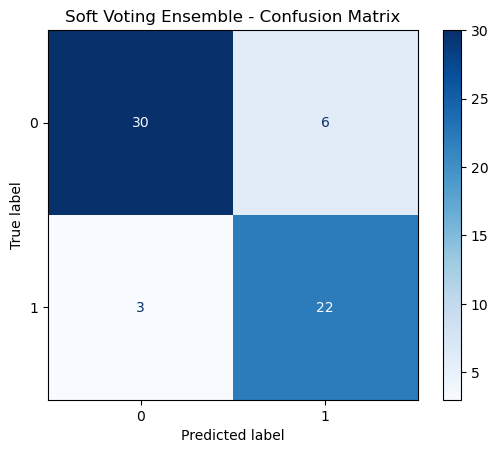

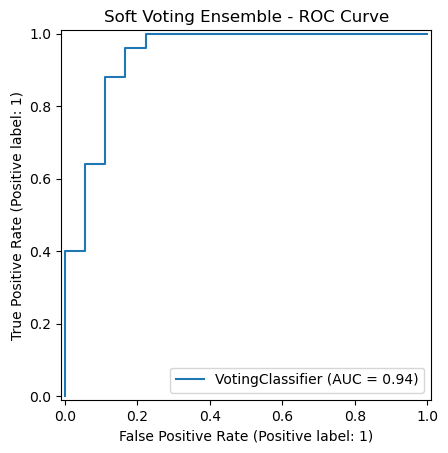

Ensemble (Hard Voting) Results:
Accuracy: 0.8525
MCC:      0.7040
Classification Report (Hard Voting Ensemble):
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        36
           1       0.79      0.88      0.83        25

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



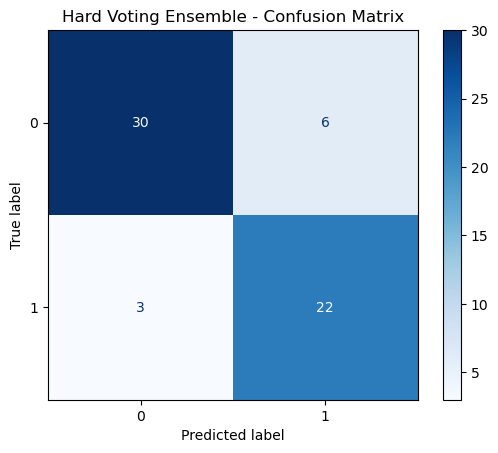

In [45]:
model_lgr_ens = LogisticRegression(random_state=192)
model_rf_ens = RandomForestClassifier(random_state=192)
model_knr_ens = KNeighborsClassifier(n_neighbors=24) # using the tuned model_knr model

ensemble = VotingClassifier(estimators=[('lr', model_lgr_ens),('model_rf', model_rf_ens),('model_knr', model_knr_ens)],voting='soft')

ensembleHard = VotingClassifier(estimators=[('lr', model_lgr_ens),('model_rf', model_rf_ens),('model_knr', model_knr_ens)],voting='hard')

ensemble.fit(X_train, y_train)
ensembleHard.fit(X_train, y_train)

y_pred_ensemble = ensemble.predict(X_test)
y_pred_ensembleHard = ensembleHard.predict(X_test)

#Evaluate
accuracy_ens = accuracy_score(y_test, y_pred_ensemble)
mcc_ens = matthews_corrcoef(y_test, y_pred_ensemble)

accuracy_ensHard = accuracy_score(y_test, y_pred_ensembleHard)
mcc_ensHard = matthews_corrcoef(y_test, y_pred_ensembleHard)

print(f"\nEnsemble (Soft Voting) Results:\n{classification_report(y_test, y_pred_ensemble)}\nAccuracy: {accuracy_ens:.4f}, MCC: {mcc_ens:.4f}")

ConfusionMatrixDisplay.from_estimator(ensemble, X_test, y_test, cmap='Blues')
plt.title("Soft Voting Ensemble - Confusion Matrix")
plt.show()

RocCurveDisplay.from_estimator(ensemble, X_test, y_test)
plt.title("Soft Voting Ensemble - ROC Curve")
plt.show()


print(f"\nEnsemble (Hard Voting) Results:\n{classification_report(y_test, y_pred_ensembleHard)}\nAccuracy: {accuracy_ensHard:.4f}, MCC: {mcc_ensHard:.4f}")


ConfusionMatrixDisplay.from_estimator(ensembleHard, X_test, y_test, cmap='Blues')
plt.title("Hard Voting Ensemble - Confusion Matrix")
plt.show()

## Comparison of tuned KNR model and Top 3 algorithm's Ensemble


Final Comparison:


,Accuracy,MCC
model_knr (Tuned),0.852459,0.713757
Voting Ensemble (Soft),0.852459,0.704008
Voting Ensemble (Hard),0.852459,0.704008


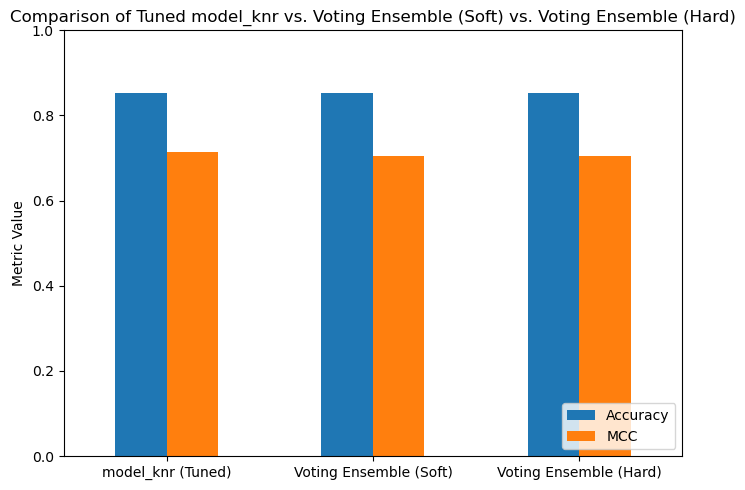

In [47]:
model_comparison = {
    "model_knr (Tuned)": {"Accuracy": accuracy_model_knr_best,"MCC": mcc_model_knr_best},
    "Voting Ensemble (Soft)": {"Accuracy": accuracy_ens,"MCC": mcc_ens},
    "Voting Ensemble (Hard)": {"Accuracy": accuracy_ensHard,"MCC": mcc_ensHard}
}

comparison_df = pd.DataFrame(model_comparison).T
print("\nFinal Comparison:")
display(comparison_df)

comparison_df.plot(kind='bar', figsize=(7,5))
plt.title("Comparison of Tuned KNR vs. Voting Ensemble (Soft) vs. Voting Ensemble (Hard)")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
